In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

trousers_ts = pd.read_csv('../data/processed/trousers_daily_sales.csv', parse_dates=['date'])
jackets_ts = pd.read_csv('../data/processed/jackets_daily_sales.csv', parse_dates=['date'])

print(trousers_ts.shape, jackets_ts.shape)
trousers_ts.head()

(3670, 3) (2200, 3)


,date,fit_category,units_sold
0,2018-09-20,tapered,1853
1,2018-09-20,straight,715
2,2018-09-20,skinny_slim,5007
3,2018-09-20,wide_relaxed,242
4,2018-09-20,regular,97


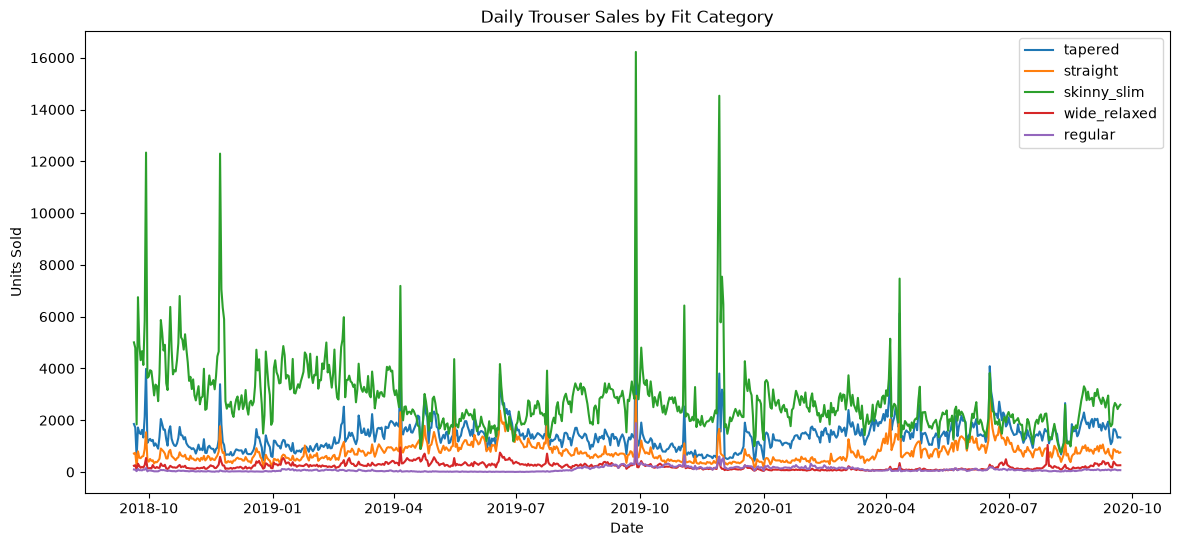

In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

for category in trousers_ts['fit_category'].unique():
    subset = trousers_ts[trousers_ts['fit_category'] == category]
    ax.plot(subset['date'], subset['units_sold'], label=category)

ax.set_title('Daily Trouser Sales by Fit Category')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()
plt.show()

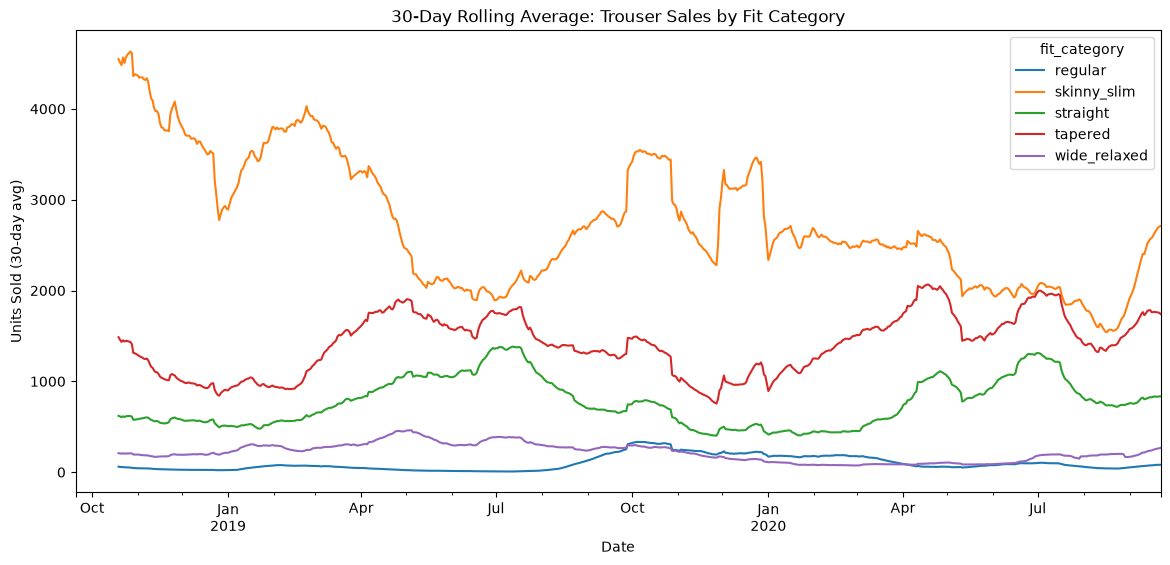

In [3]:
trousers_pivot = trousers_ts.pivot(index='date', columns='fit_category', values='units_sold')
trousers_smooth = trousers_pivot.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))
trousers_smooth.plot(ax=ax)
ax.set_title('30-Day Rolling Average: Trouser Sales by Fit Category')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold (30-day avg)')
plt.show()

In [4]:
articles_check = pd.read_csv('../data/interim/trousers_tagged.csv')

trouser_articles = duckdb.sql("""
    SELECT 
        t.t_dat AS date,
        tr.fit_category,
        COUNT(DISTINCT t.article_id) AS distinct_products_sold
    FROM '../data/raw/transactions_train.csv' t
    JOIN '../data/interim/trousers_tagged.csv' tr
        ON t.article_id = tr.article_id
    GROUP BY t.t_dat, tr.fit_category
    ORDER BY t.t_dat
""").df()

articles_pivot = trouser_articles.pivot(index='date', columns='fit_category', values='distinct_products_sold')
articles_smooth = articles_pivot.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))
articles_smooth.plot(ax=ax)
ax.set_title('30-Day Rolling Avg: Distinct Products Sold per Day, by Fit Category')
ax.set_xlabel('Date')
ax.set_ylabel('Distinct Products (30-day avg)')
plt.show()

NameError: name 'duckdb' is not defined

In [5]:
import duckdb

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

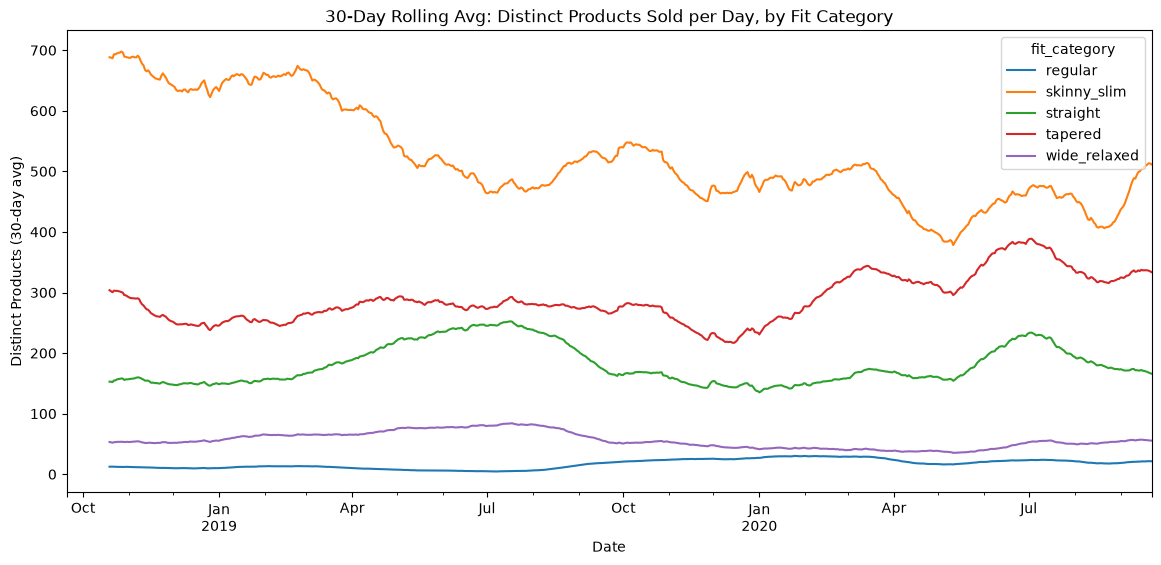

In [7]:
articles_check = pd.read_csv('../data/interim/trousers_tagged.csv')

trouser_articles = duckdb.sql("""
    SELECT 
        t.t_dat AS date,
        tr.fit_category,
        COUNT(DISTINCT t.article_id) AS distinct_products_sold
    FROM '../data/raw/transactions_train.csv' t
    JOIN '../data/interim/trousers_tagged.csv' tr
        ON t.article_id = tr.article_id
    GROUP BY t.t_dat, tr.fit_category
    ORDER BY t.t_dat
""").df()

articles_pivot = trouser_articles.pivot(index='date', columns='fit_category', values='distinct_products_sold')
articles_smooth = articles_pivot.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))
articles_smooth.plot(ax=ax)
ax.set_title('30-Day Rolling Avg: Distinct Products Sold per Day, by Fit Category')
ax.set_xlabel('Date')
ax.set_ylabel('Distinct Products (30-day avg)')
plt.show()

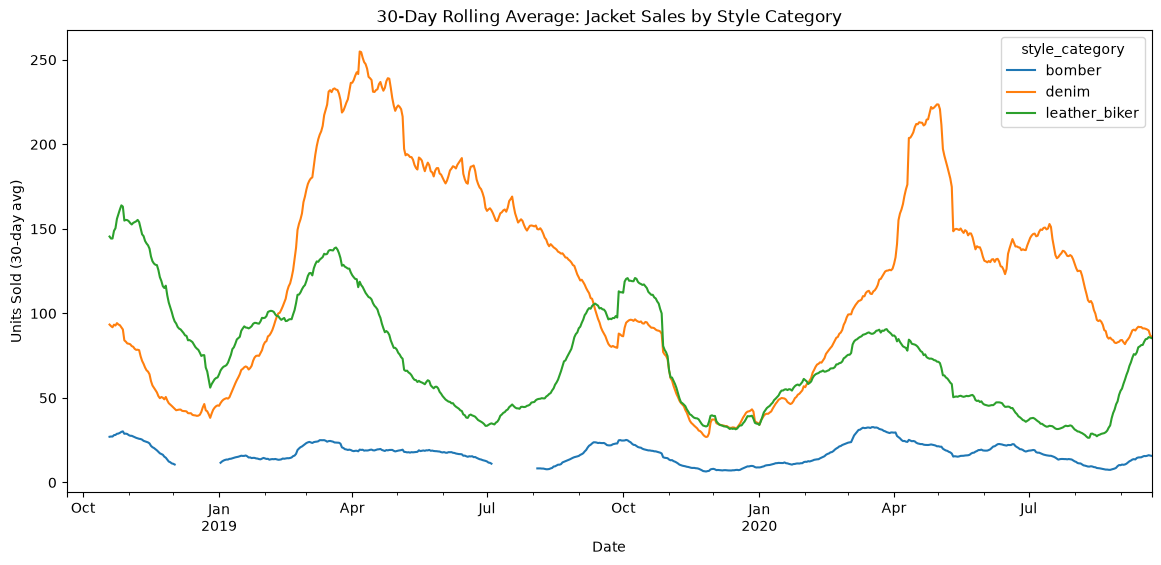

In [8]:
jackets_pivot = jackets_ts.pivot(index='date', columns='style_category', values='units_sold')
jackets_smooth = jackets_pivot.rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))
jackets_smooth.plot(ax=ax)
ax.set_title('30-Day Rolling Average: Jacket Sales by Style Category')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold (30-day avg)')
plt.show()